# 53 Boost Sale — XGBoost con features completas (Sale)

Replica exactamente el componente **boost** del notebook `53_boost_def_3`:

- Mismos **hiperparámetros** hardcodeados (los que dan R²≈0.818 en test)
- **Todas las features**: BASE_FEATURES + todos los `municipio_*` OHE del gold
- Eliminación de outliers con **IQR×1.5** sobre `log_precio`
- **Sin búsqueda**: no hay Optuna — entrenamiento directo

Los params exportables se muestran en la sección 8 para copiar a `55_sale_rent_models`.

## Configuracion y rutas
Parametros globales y definicion de datasets.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score,
)
from sklearn.model_selection import train_test_split, KFold, cross_val_score

from xgboost import XGBRegressor

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 300)
pd.set_option("display.width", 220)

# ── Configuración ──────────────────────────────────────────────────────────────
RANDOM_STATE      = 42
TEST_SIZE         = 0.20
TARGET_COL        = "log_precio"
CV_FOLDS          = 5
IQR_FACTOR        = 1.5
MIN_MUNI_OBS      = 10
PRECIO_M2_MIN     = 1000   # €/m² — por debajo: anomalías (ruinas, rurales extremas, errores)

# ── Rutas ──────────────────────────────────────────────────────────────────────
def find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "data" / "gold").exists():
            return p
    raise FileNotFoundError("No se encontró la raíz del proyecto (data/gold)")

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
SALE_PATH    = PROJECT_ROOT / "data" / "gold" / "final_sale_idealistaAPI.csv"

print(f"Proyecto: {PROJECT_ROOT}")
print(f"Dataset sale: {SALE_PATH}")

Proyecto: /Users/sitomachucas/Documents/BezanillaSL
Dataset sale: /Users/sitomachucas/Documents/BezanillaSL/data/gold/final_sale_idealistaAPI.csv


## 1. Carga y exploración inicial

Filas totales: 2694
Columnas: 71

Nulos por columna:
planta          1335
distrito         793
subtipologia    1628
dtype: int64


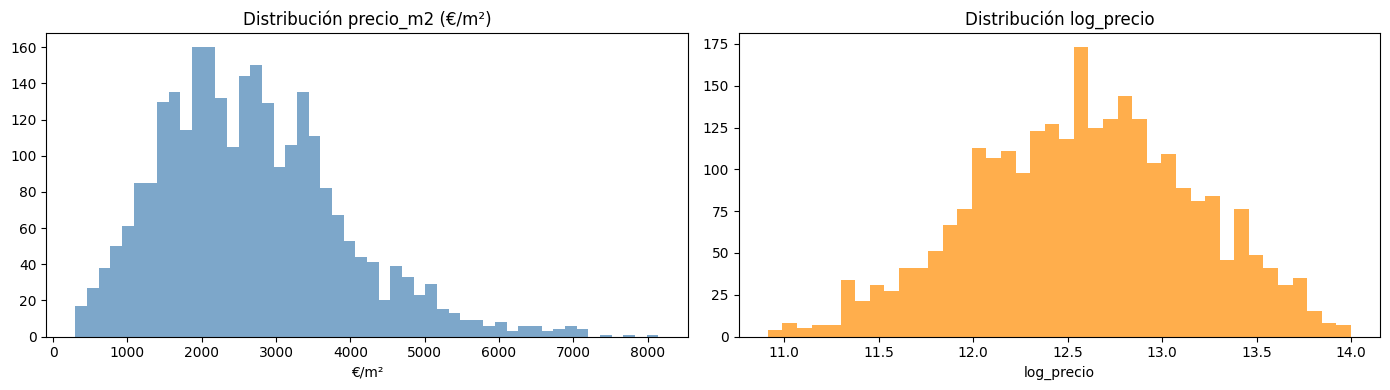


Estadísticas log_precio:
count    2694.0000
mean       12.5822
std         0.5852
min        10.9133
25%        12.1548
50%        12.6048
75%        12.9945
max        13.9978
Name: log_precio, dtype: float64


In [2]:
df_raw = pd.read_csv(SALE_PATH)
print(f"Filas totales: {len(df_raw)}")
print(f"Columnas: {df_raw.shape[1]}")
print(f"\nNulos por columna:")
print(df_raw.isnull().sum()[df_raw.isnull().sum() > 0])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df_raw["precio_m2"].dropna(), bins=50, color="steelblue", alpha=0.7)
axes[0].set_title("Distribución precio_m2 (€/m²)")
axes[0].set_xlabel("€/m²")
axes[1].hist(df_raw[TARGET_COL].dropna(), bins=40, color="darkorange", alpha=0.7)
axes[1].set_title(f"Distribución {TARGET_COL}")
axes[1].set_xlabel(TARGET_COL)
plt.tight_layout()
plt.show()

print(f"\nEstadísticas {TARGET_COL}:")
print(df_raw[TARGET_COL].describe().round(4))

## 2. Limpieza de outliers

Dos pasos:
1. **IQR×1.5 sobre `log_precio`**: elimina extremos de precio absoluto (0 filas en sale)
2. **Suelo de `precio_m2`**: elimina propiedades anómalamente baratas por m² (ruinas, errores, no-residencial) — responsables de la cola inferior en el Q-Q plot (residuos hasta −1.25)

In [3]:
df = df_raw[df_raw[TARGET_COL].notna()].copy()
print(f"Filas con {TARGET_COL} válido: {len(df)}")

# ── Paso 1: IQR×1.5 sobre log_precio ──────────────────────────────────────────
q1, q3 = df[TARGET_COL].quantile([0.25, 0.75])
iqr = q3 - q1
lo, hi = q1 - IQR_FACTOR * iqr, q3 + IQR_FACTOR * iqr
mask_iqr = df[TARGET_COL].between(lo, hi)
print(f"Paso 1 — IQR×{IQR_FACTOR} log_precio eliminados: {(~mask_iqr).sum()} ({(~mask_iqr).mean()*100:.1f}%)")
print(f"  Rango válido: [{lo:.3f}, {hi:.3f}]  →  precio [{np.exp(lo):.0f} €, {np.exp(hi):.0f} €]")
df = df[mask_iqr].copy()

# ── Paso 2: suelo de precio_m2 ────────────────────────────────────────────────
# Propiedades con precio_m2 muy bajo no responden a la lógica del mercado
# residencial — son ruinas, no-residencial, o errores de datos.
# Responsables de la cola inferior del Q-Q plot (residuos hasta −1.25).
mask_m2_min = df["precio_m2"] >= PRECIO_M2_MIN
print(f"\nPaso 2 — Suelo precio_m2 < {PRECIO_M2_MIN} €/m² eliminados: {(~mask_m2_min).sum()} ({(~mask_m2_min).mean()*100:.1f}%)")
if (~mask_m2_min).sum() > 0:
    print("  Propiedades eliminadas:")
    cols_show = ["precio_m2", TARGET_COL, "superficie_construida_m2", "numero_dormitorios", "numero_banos"]
    cols_show = [c for c in cols_show if c in df.columns]
    print(df[~mask_m2_min][cols_show].to_string())
df = df[mask_m2_min].copy()

print(f"\nFilas finales para modelar: {len(df)}")

Filas con log_precio válido: 2694
Paso 1 — IQR×1.5 log_precio eliminados: 0 (0.0%)
  Rango válido: [10.895, 14.254]  →  precio [53914 €, 1550605 €]

Paso 2 — Suelo precio_m2 < 1000 €/m² eliminados: 151 (5.6%)
  Propiedades eliminadas:
       precio_m2  log_precio  superficie_construida_m2  numero_dormitorios  numero_banos
25    902.077670   11.439430                     103.0                   1             1
35    909.090909   12.542545                     308.0                   5             2
139   357.798165   12.180755                     545.0                   0             0
233   792.000000   12.196022                     250.0                   3             2
236   882.352941   12.948010                     476.0                   0             0
293   492.882562   12.531773                     562.0                   4             2
297   765.432099   11.728037                     162.0                   0             0
298   492.882562   12.531773                     562.

## 3. Features y funciones auxiliares

In [4]:
BASE_FEATURES = [
    "superficie_construida_m2",
    "numero_dormitorios",
    "numero_banos",
    # "latitud",
    # "longitud",
    "planta_num",
    # "es_exterior_piso",
    # "tiene_ascensor_piso",
    "tiene_garaje",
    "obra_nueva",
    "distancia_min_playa_km",
    "distancia_min_supermercado_km",
    "distancia_min_colegio_km",
    "precio_m2_municipio_media",
    "ratio_dormitorios_superficie",
    "ratio_banos_superficie",
    "interaccion_planta_sin_ascensor_piso",
    "distancia_centro_municipio_km",
    "score_cercania_servicios",
    "tipologia_unificada_piso",
    "tipologia_unificada_unifamiliar",
    # municipio_* se añaden dinámicamente
]


def build_X(df: pd.DataFrame) -> tuple:
    df2 = df.copy()
    base = [f for f in BASE_FEATURES if f in df2.columns]
    mun_cols = sorted([c for c in df2.columns if c.startswith("municipio_")])
    if mun_cols:
        counts = df2[mun_cols].sum()
        small  = counts[counts < MIN_MUNI_OBS].index.tolist()
        if small:
            df2["municipio_otros"] = df2[small].max(axis=1)
            df2 = df2.drop(columns=small)
        mun_final = sorted(c for c in df2.columns if c.startswith("municipio_"))
    else:
        mun_final = []
    all_feats = base + [m for m in mun_final if m not in base]
    X = df2[all_feats].copy()
    imputer = SimpleImputer(strategy="median")
    X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)
    return X, all_feats


def get_metrics(y_real, y_pred) -> pd.DataFrame:
    mse = mean_squared_error(y_real, y_pred)
    return pd.DataFrame({
        "MSE":  [round(float(mse), 5)],
        "RMSE": [round(float(np.sqrt(mse)), 5)],
        "MAE":  [round(float(mean_absolute_error(y_real, y_pred)), 5)],
        "R2":   [round(float(r2_score(y_real, y_pred)), 5)],
        "MAPE": [round(float(mean_absolute_percentage_error(y_real, y_pred)), 5)],
    })


def plot_diagnostics(y_test, pred_test, title_prefix: str):
    residuals = y_test - pred_test
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    ax = axes[0]
    ax.scatter(y_test, pred_test, alpha=0.5, s=15)
    lim = [min(y_test.min(), pred_test.min()), max(y_test.max(), pred_test.max())]
    ax.plot(lim, lim, "r--", linewidth=1)
    ax.set_title(f"{title_prefix} | Real vs Predicho")
    ax.set_xlabel(f"Real ({TARGET_COL})")
    ax.set_ylabel(f"Predicho ({TARGET_COL})")
    ax = axes[1]
    ax.hist(residuals, bins=30, alpha=0.7, color="steelblue")
    ax.axvline(0, color="red", linestyle="--", linewidth=1)
    ax.set_title(f"{title_prefix} | Residuos (test)")
    ax.set_xlabel("Residuo (real − predicho)")
    ax.set_ylabel("Frecuencia")
    ax = axes[2]
    stats.probplot(residuals, dist="norm", plot=ax)
    ax.set_title(f"{title_prefix} | Q-Q plot residuos")
    plt.tight_layout()
    plt.show()


def plot_feature_importance(importances, feature_names, title, top_n=20):
    fi = (
        pd.DataFrame({"feature": feature_names, "importance": importances})
        .sort_values("importance", ascending=False)
        .head(top_n)
    )
    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh(fi["feature"][::-1], fi["importance"][::-1], color="steelblue")
    ax.set_title(title)
    ax.set_xlabel("Importancia")
    plt.tight_layout()
    plt.show()
    return fi


X, feats = build_X(df)
y = df[TARGET_COL].values
print(f"Features ({len(feats)}):")
print(feats)

Features (48):
['superficie_construida_m2', 'numero_dormitorios', 'numero_banos', 'planta_num', 'tiene_garaje', 'obra_nueva', 'distancia_min_playa_km', 'distancia_min_supermercado_km', 'distancia_min_colegio_km', 'precio_m2_municipio_media', 'ratio_dormitorios_superficie', 'ratio_banos_superficie', 'interaccion_planta_sin_ascensor_piso', 'distancia_centro_municipio_km', 'score_cercania_servicios', 'tipologia_unificada_piso', 'tipologia_unificada_unifamiliar', 'municipio_Ampuero', 'municipio_Barcena de Cicero', 'municipio_Camargo', 'municipio_Castro-Urdiales', 'municipio_Colindres', 'municipio_Cudon', 'municipio_El Astillero', 'municipio_Guarnizo', 'municipio_Laredo', 'municipio_Liendo', 'municipio_Limpias', 'municipio_Marina de Cudeyo', 'municipio_Miengo', 'municipio_Mogro', 'municipio_Noja', 'municipio_Ortuella', 'municipio_Piélagos', 'municipio_Polanco', 'municipio_Ribamontan al Mar', 'municipio_Ribamontan al Monte', 'municipio_Santa Cruz de Bezana', 'municipio_Santander', 'municipio

In [5]:
# ── Investigación: ¿por qué numero_banos puede salir como top feature? ─────────
print("Correlaciones con log_precio:")
for col in ["numero_banos", "superficie_construida_m2", "numero_dormitorios", "precio_m2_municipio_media"]:
    if col in df.columns:
        print(f"  {col}: {df[col].corr(df[TARGET_COL]):.4f}")

print(f"\nnumero_banos distribución (tras limpieza):")
print(df["numero_banos"].value_counts().sort_index().to_string())
print(f"\nResumen: numero_banos tiene la correlación lineal más alta con log_precio "
      f"({df['numero_banos'].corr(df[TARGET_COL]):.4f}) — su importancia es legítima.")

Correlaciones con log_precio:
  numero_banos: 0.6228
  superficie_construida_m2: 0.6945
  numero_dormitorios: 0.5500
  precio_m2_municipio_media: 0.1335

numero_banos distribución (tras limpieza):
numero_banos
0       18
1      901
2     1006
3      418
4      132
5       46
6       16
7        3
10       2
11       1

Resumen: numero_banos tiene la correlación lineal más alta con log_precio (0.6228) — su importancia es legítima.


## 4. Split train / test

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)
print(f"Train: {len(X_train)} | Test: {len(X_test)} | Features: {X.shape[1]}")

Train: 2034 | Test: 509 | Features: 48


## 5. Hiperparámetros y entrenamiento directo

Parámetros hardcodeados idénticos a `53_boost_def_3`.  
Sin búsqueda de hiperparámetros — entrenamiento directo sobre train.

In [7]:
XGB_PARAMS = dict(
    n_estimators     = 400,
    max_depth        = 4,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    min_child_weight = 3,
    reg_lambda       = 3,
    random_state     = RANDOM_STATE,
    n_jobs           = -1,
    verbosity        = 0,
)

model = XGBRegressor(**XGB_PARAMS)
model.fit(X_train, y_train)

kf = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
cv_rmse = float(-cross_val_score(
    XGBRegressor(**XGB_PARAMS), X_train, y_train,
    cv=kf, scoring="neg_root_mean_squared_error", n_jobs=-1
).mean())

print(f"CV-RMSE (5-fold, train): {cv_rmse:.5f}")
print("\nHiperparámetros:")
for k, v in XGB_PARAMS.items():
    print(f"  {k}: {v}")

CV-RMSE (5-fold, train): 0.25111

Hiperparámetros:
  n_estimators: 400
  max_depth: 4
  learning_rate: 0.05
  subsample: 0.8
  colsample_bytree: 0.8
  min_child_weight: 3
  reg_lambda: 3
  random_state: 42
  n_jobs: -1
  verbosity: 0


## 6. Modelo final con mejores hiperparámetros

In [8]:
m_train = get_metrics(y_train, model.predict(X_train))
m_test  = get_metrics(y_test,  model.predict(X_test))

summary = pd.concat([
    m_train.assign(split="train"),
    pd.DataFrame({"split": ["CV"], "MSE": [None],
                  "RMSE": [round(cv_rmse, 5)],
                  "MAE": [None], "R2": [None], "MAPE": [None]}),
    m_test.assign(split="test"),
], ignore_index=True)[["split", "MSE", "RMSE", "MAE", "R2", "MAPE"]]

print(f"\n{summary.to_string(index=False)}")

delta_r2 = float(m_train["R2"].iloc[0]) - float(m_test["R2"].iloc[0])
ratio    = float(m_test["RMSE"].iloc[0]) / max(float(m_train["RMSE"].iloc[0]), 1e-9)
print(f"\nSobreajuste → ratio RMSE test/train: {ratio:.4f} | delta R²: {delta_r2:.4f}")


split     MSE    RMSE     MAE      R2    MAPE
train 0.02480 0.15747 0.11509 0.92387 0.00918
   CV     NaN 0.25111     NaN     NaN     NaN
 test 0.06033 0.24562 0.18063 0.82054 0.01451

Sobreajuste → ratio RMSE test/train: 1.5598 | delta R²: 0.1033


## 7. Diagnósticos

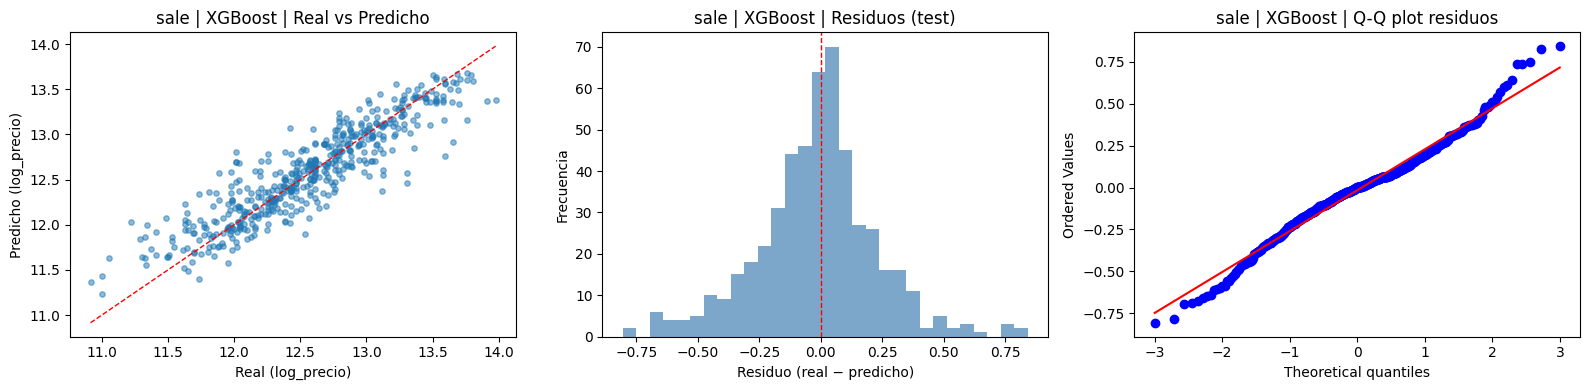

In [9]:
plot_diagnostics(y_test, model.predict(X_test), "sale | XGBoost")

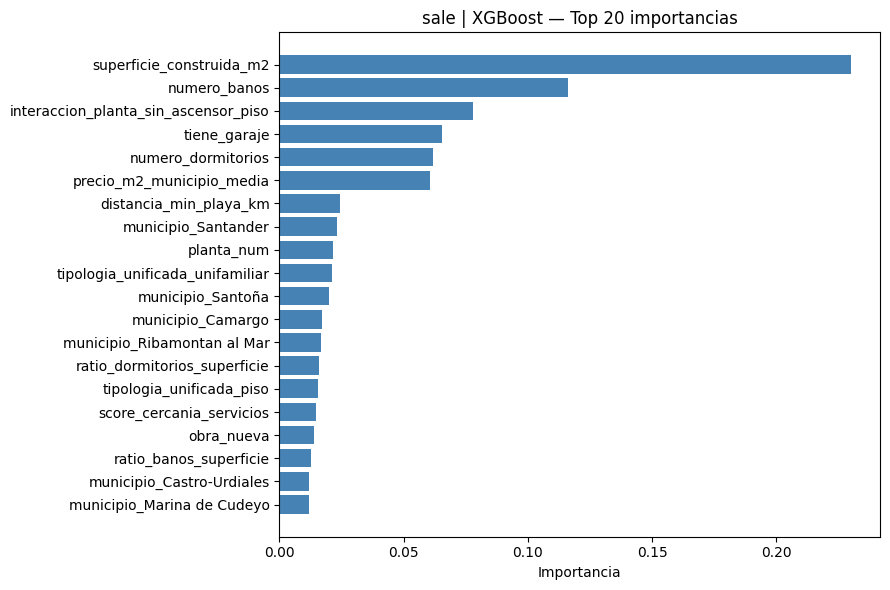

                             feature  importance
            superficie_construida_m2    0.230198
                        numero_banos    0.116207
interaccion_planta_sin_ascensor_piso    0.077980
                        tiene_garaje    0.065367
                  numero_dormitorios    0.061679
           precio_m2_municipio_media    0.060737
              distancia_min_playa_km    0.024354
                 municipio_Santander    0.023344
                          planta_num    0.021423
     tipologia_unificada_unifamiliar    0.021112
                   municipio_Santoña    0.019805
                   municipio_Camargo    0.017294
         municipio_Ribamontan al Mar    0.016892
        ratio_dormitorios_superficie    0.015851
            tipologia_unificada_piso    0.015509
            score_cercania_servicios    0.014691
                          obra_nueva    0.013718
              ratio_banos_superficie    0.012750
           municipio_Castro-Urdiales    0.012059
          municipio_

In [10]:
fi = plot_feature_importance(
    model.feature_importances_, feats,
    "sale | XGBoost — Top 20 importancias"
)
print(fi.to_string(index=False))

## 8. Resumen y parámetros exportables

In [11]:
print("=" * 80)
print("RESUMEN FINAL — XGBoost Sale")
print("=" * 80)
print(f"  Target             : {TARGET_COL}")
print(f"  Filas tras limpieza: {len(df)}")
print(f"  Features           : {len(feats)}")
print(f"  CV-RMSE (train)    : {cv_rmse:.5f}")
print(f"  Test RMSE          : {float(m_test['RMSE'].iloc[0]):.5f}")
print(f"  Test R²            : {float(m_test['R2'].iloc[0]):.5f}")
print()
params_export = {k: v for k, v in XGB_PARAMS.items()
                 if k not in ("random_state", "n_jobs", "verbosity")}
print("Hiperparámetros (para copiar a 55_sale_rent_models):")
print(f"  XGB_PARAMS_SALE   = {params_export}")
print(f"  XGB_FEATURES_SALE = {feats}")

RESUMEN FINAL — XGBoost Sale
  Target             : log_precio
  Filas tras limpieza: 2543
  Features           : 48
  CV-RMSE (train)    : 0.25111
  Test RMSE          : 0.24562
  Test R²            : 0.82054

Hiperparámetros (para copiar a 55_sale_rent_models):
  XGB_PARAMS_SALE   = {'n_estimators': 400, 'max_depth': 4, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 3, 'reg_lambda': 3}
  XGB_FEATURES_SALE = ['superficie_construida_m2', 'numero_dormitorios', 'numero_banos', 'planta_num', 'tiene_garaje', 'obra_nueva', 'distancia_min_playa_km', 'distancia_min_supermercado_km', 'distancia_min_colegio_km', 'precio_m2_municipio_media', 'ratio_dormitorios_superficie', 'ratio_banos_superficie', 'interaccion_planta_sin_ascensor_piso', 'distancia_centro_municipio_km', 'score_cercania_servicios', 'tipologia_unificada_piso', 'tipologia_unificada_unifamiliar', 'municipio_Ampuero', 'municipio_Barcena de Cicero', 'municipio_Camargo', 'municipio_Castro-Urdiales